In [1]:
from   matplotlib        import pyplot as plt
from   scipy.interpolate import CubicSpline
import numpy             as np
from   UTILS             import InitialCondition_3d
from   scipy.stats       import maxwell
from UTILS import step_all_particles, dt, harmonic_degree, harmonic_coefficient, BfieldExtended
import time

/home/adriano/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


# Costants

In [2]:
# Constants class, values are loaded from UTILS.py
from UTILS import mass, dt, bohr_magneton, kB
from UTILS import Temperature, Temperature_transv
from UTILS import Zmin, Zmax, Zmid, zacceptance_min, zacceptance_max
from UTILS import harmonic_degree, harmonic_coefficient

In [90]:
Temperature        = 2e-3 # K
Temperature_transv = 10e-3 # K
theta              = 0
tau_mixing         = 1e6
stringa            = ""

class constants:
    def __init__(self, 
                 mass, 
                 dt, 
                 bohr_magneton,
                 kB,
                 Temperature,
                 Temperature_transv,
                 Zmin,
                 Zmax,
                 Zmid,
                 zacceptance_min,
                 zacceptance_max,
                 harmonic_degree,
                 harmonic_coefficient,
                 tau_mixing):
        self.mass = mass
        self.dt = dt
        self.bohr_magneton = bohr_magneton
        self.kB = kB
        self.Temperature = Temperature
        self.Temperature_transv = Temperature_transv
        self.Zmin = Zmin
        self.Zmax = Zmax
        self.Zmid = Zmid
        self.zacceptance_min = zacceptance_min
        self.zacceptance_max = zacceptance_max
        self.harmonic_degree = harmonic_degree
        self.harmonic_coefficient = harmonic_coefficient
        self.tau_mixing = tau_mixing
    mu_eff_over_m = bohr_magneton / mass

CONSTANTS = constants(mass, 
                 dt, 
                 bohr_magneton,
                 kB,
                 Temperature,
                 Temperature_transv,
                 Zmin,
                 Zmax,
                 Zmid,
                 zacceptance_min,
                 zacceptance_max,
                 harmonic_degree,
                 harmonic_coefficient,
                 tau_mixing)

print(CONSTANTS.Temperature, CONSTANTS.Temperature_transv)

0.002 0.01


# Functions to make the plot nicer

In [91]:
# Make Plot Nicer
def plotter_nicer(titlex, titley):
    plt.ylabel(titley, fontsize = 18, loc = "top")
    plt.xlabel(titlex, loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

def labelfactory(x, y , listlist, labels):
    plt.xticks(labels,[f"{item:.2f}g" for item in labels], rotation = 30)      # etichette

    texts = []
    for xi, yi, label in zip(x, y, listlist):
        texts.append(plt.text(xi - 0.2, yi, label, rotation = 30))
    
    adjust_text(texts, x, y, arrowprops=dict(arrowstyle="->", color='white'))
    
    plt.legend(fontsize = 12)

In [92]:
def function(x, N, sigma):
    Np = N / np.sqrt(2 * np.pi * sigma**2)
    return Np * np.exp( - x*x / (2 * sigma * sigma))

def sigmaToTemperature(sigma, Kb, m):
    return sigma**2 * m / Kb

def TemperatureTosigma(T,Kb,m):
    return np.sqrt(Kb * T / m)

def sigmaToTemperature_n(sigma, Kb, m):
    return m * sigma**2 / Kb

def sigmaToTemperature_3(sigmax, sigmay, sigmaz, Kb, m):
    return m * (sigmax**2 + sigmay**2 + sigmaz**2) / ( 3 * Kb)

# TEST ENERGY, POSITION, MAGNETIC FIELD MAPS

## Boltzmann-Maxwell distribution

0.0019845094393000184


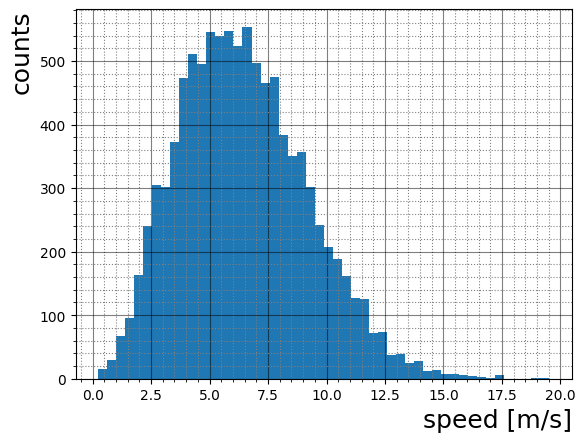

In [93]:
scale = np.sqrt(CONSTANTS.kB * 2e-3 / CONSTANTS.mass)
vx = np.random.normal(0, scale, size=10000)
vy = np.random.normal(0, scale, size=10000)
vz = np.random.normal(0, scale, size=10000)

v = np.sqrt(vx*vx + vy*vy + vz*vz)

plt.hist(v, bins = 50, label = "T")
plotter_nicer("speed [m/s]", "counts")

vrms = np.std(vx)

print(sigmaToTemperature(vrms, CONSTANTS.kB, CONSTANTS.mass))

## Plot of the Magnetic field profile, 20mT well

In [94]:
data = np.genfromtxt("Bfield_notebook/PreGravity_20mT_well_0p0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['z_mm__Bz_on_axis']/1000

print(type(data))
print(10*"-")
print(data)
print(10*"-")
print(data[0])
print(10*"-")
print(data[0][0], data[0][1] )
print(10*"-")
print(data["z_mm__Bz_on_axis"])
#Z, Potential, Z_minwall, PotentialMinWall 

<class 'numpy.ndarray'>
----------
[(-2599.48, 0.00118259) (-2598.96, 0.0011841 ) (-2598.44, 0.00118563) ...
 ( 2598.44, 0.00138514) ( 2598.96, 0.0013834 ) ( 2599.48, 0.00138165)]
----------
(-2599.48, 0.00118259)
----------
-2599.4799999999996 0.001182594539963945
----------
[-2599.48 -2598.96 -2598.44 ...  2598.44  2598.96  2599.48]


<ErrorbarContainer object of 3 artists>

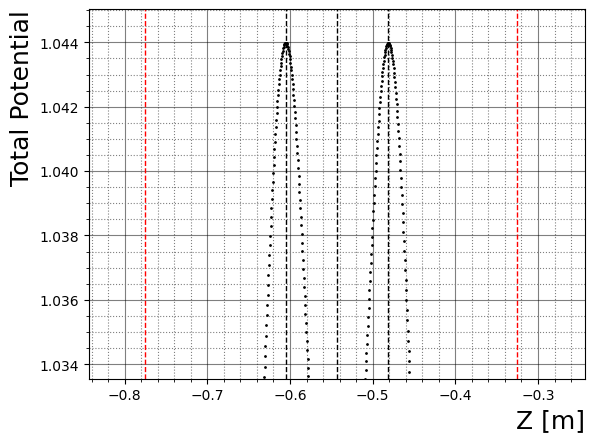

In [95]:
plotter_nicer("Z [m]", "Total Potential")

plt.xlim(CONSTANTS.Zmid -0.3, CONSTANTS.Zmid + 0.3)
massimo = np.max(data["Total_potential_T__Bz_on_axis"]); plt.ylim(massimo*0.990, massimo*1.001)

plt.axvline(CONSTANTS.Zmax, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.Zmin, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.Zmid, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.zacceptance_min, linestyle = "--", color = "red", linewidth = 1)
plt.axvline(CONSTANTS.zacceptance_max, linestyle = "--", color = "red", linewidth = 1)
plt.errorbar(data['z_mm__Bz_on_axis']/1000,data["Total_potential_T__Bz_on_axis"], linestyle = '', marker = '.', markersize = 2, color = "black")

## Spline Creation

- **Bfield(x)** Magnetic Field Potential

In [96]:
Z = data['z_mm__Bz_on_axis']/1000
print(Z)
Uz = data["Total_potential_T__Bz_on_axis"]

# # Modify the potential to check the bias
# mask = (Z > -0.5) & (Z < -0.47)
# Uz[mask] = Uz[mask]# + 0.00007

Bfield = CubicSpline(Z, Uz)

[-2.59948 -2.59896 -2.59844 ...  2.59844  2.59896  2.59948]


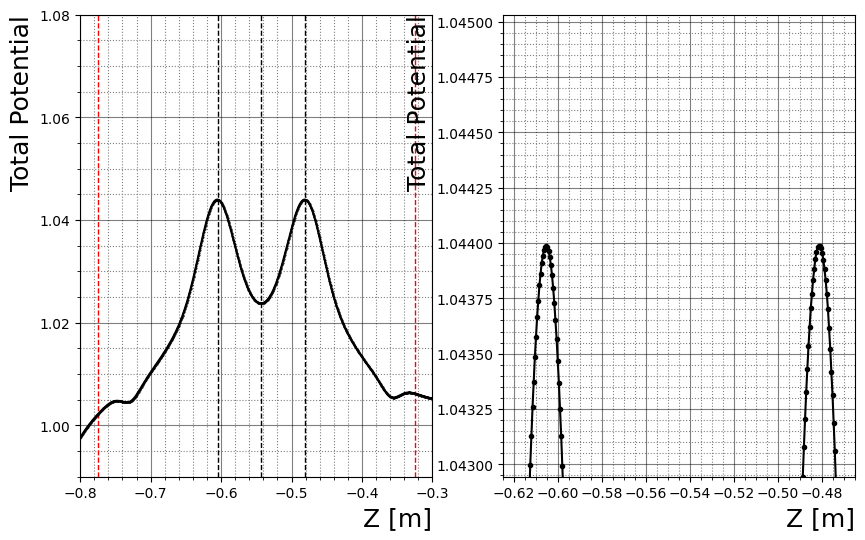

In [97]:
plt.figure(1243, figsize = (10, 6))
plt.subplot(1,2,1)
plotter_nicer("Z [m]", "Total Potential")

plt.axvline(CONSTANTS.Zmax, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.Zmin, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.Zmid, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.zacceptance_min, linestyle = "--", color = "red", linewidth = 1)
plt.axvline(CONSTANTS.zacceptance_max, linestyle = "--", color = "red", linewidth = 1)

plt.xlim(-0.800, -0.300)
plt.ylim(.99, 1.08)

plt.plot(Z, Bfield(Z), linestyle = "-", linewidth = 0.5, color = "red")
plt.plot(Z,data["Total_potential_T__Bz_on_axis"], marker = ".", markersize = 1, color = "black")

plt.subplot(1,2,2)
plotter_nicer("Z [m]", "Total Potential")

plt.xlim(-0.625, -0.465)
massimo = np.max(data["Total_potential_T__Bz_on_axis"]); plt.ylim(massimo*0.999, massimo*1.001)

plt.plot(Z, Bfield(Z), linestyle = "-", linewidth = 0.5, color = "red")
plt.plot(Z,data["Total_potential_T__Bz_on_axis"], marker = ".", color = "black")

## Energy Distribution

In [98]:
nAtoms = 5000

total energy  2.284298295353099e-26 Max Energy  1.8750733888240268e-25
total energy  2.8328929784365855e-27 Max Energy  1.8750733888240268e-25
total energy  7.295232027541871e-27 Max Energy  1.8750733888240268e-25
total energy  8.671578924643754e-27 Max Energy  1.8750733888240268e-25
total energy  2.158271405915313e-27 Max Energy  1.8750733888240268e-25
total energy  2.817543106612678e-27 Max Energy  1.8750733888240268e-25
total energy  7.194357356983e-28 Max Energy  1.8750733888240268e-25
total energy  4.49419742567009e-27 Max Energy  1.8750733888240268e-25
total energy  1.3674928177811316e-26 Max Energy  1.8750733888240268e-25
total energy  2.069190297915064e-28 Max Energy  1.8750733888240268e-25
total energy  7.218242023186793e-28 Max Energy  1.8750733888240268e-25
total energy  6.4508096261011704e-27 Max Energy  1.8750733888240268e-25
total energy  1.0976161206545511e-28 Max Energy  1.8750733888240268e-25
total energy  7.454786248373351e-27 Max Energy  1.8750733888240268e-25
total 

<ErrorbarContainer object of 3 artists>

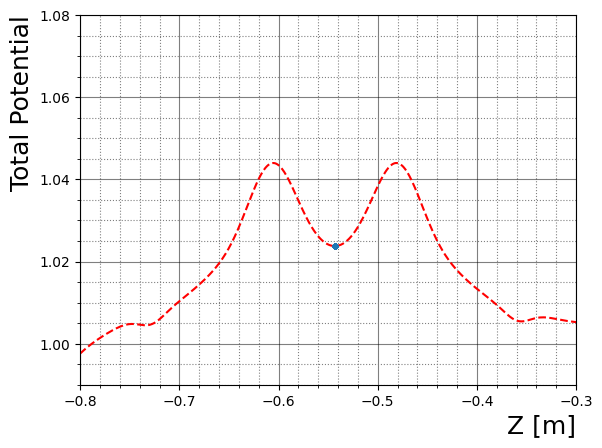

In [99]:
Zinit = [InitialCondition_3d(Bfield, CONSTANTS)[1][2] for i in range(0,nAtoms)]

plotter_nicer("Z [m]", "Total Potential")
plt.xlim(-0.800, -0.300)
plt.ylim(.99, 1.08)
plt.plot(Z, Bfield(Z), linestyle = "--", color = "red")
plt.errorbar(Zinit, Bfield(Zinit), linestyle = "", marker = ".")

# Testing 3d code

## Simulation Variables

In [100]:
V_array           = []
R_array           = []
Time_Annihilation = []
Annihilation      = []
dB_buffer         = np.empty(3, dtype=np.float64)

# def cleaner(*arrays):
#     return [np.array([]) for _ in arrays]

def cleaner(*arrays):
    "reset list"
    return tuple([] for _ in arrays)

def convert_np(*arrays):
    "convert to np array"
    return tuple(np.array(_) for _ in arrays)

In [101]:
from UTILS import Gradient_Computation_1d, dB_seg

bias = "0p0g"

In [102]:
data = np.genfromtxt(f"Bfield_notebook/PreGravity_20mT_well_0p0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['z_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_20mT_pregravity = CubicSpline(Z, Uz)

data = np.genfromtxt(f"Bfield_notebook/GravityRelease_17mT_well_{bias}.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['z_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_17mT = CubicSpline(Z, Uz)

data = np.genfromtxt(f"Bfield_notebook/GravityRelease_5mT_well_{bias}.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['z_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_5mT = CubicSpline(Z, Uz)

data = np.genfromtxt(f"Bfield_notebook/GravityRelease_2p5mT_well_{bias}.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['z_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_2p5mT = CubicSpline(Z, Uz)

[-2.59948 -2.59896 -2.59844 ...  2.59844  2.59896  2.59948] [0.00118259 0.0011841  0.00118563 ... 0.00138514 0.0013834  0.00138165]
[-2.59948 -2.59896 -2.59844 ...  2.59844  2.59896  2.59948] [0.00118247 0.00118398 0.0011855  ... 0.0013851  0.00138336 0.00138161]
[-2.59948 -2.59896 -2.59844 ...  2.59844  2.59896  2.59948] [0.00118201 0.00118352 0.00118505 ... 0.00138495 0.00138322 0.00138146]
[-2.59948 -2.59896 -2.59844 ...  2.59844  2.59896  2.59948] [0.00118192 0.00118343 0.00118495 ... 0.00138492 0.00138319 0.00138143]


## Create Magnetic field and Gradient Grid

In [103]:
zgrid = np.linspace(-0.800, -0.300, 100000)   # half mm of discretization 
z0 = zgrid[0]
dz = np.diff(zgrid)[0]

dBfield_20mT_pregravity_dz  = np.array(Gradient_Computation_1d(Bfield_20mT_pregravity, zgrid))
Bfield_20mT_pregravity_grid = np.array(Bfield_20mT_pregravity(zgrid))

dBfield_17mT_dz             = np.array(Gradient_Computation_1d(Bfield_17mT, zgrid))
Bfield_17mT_grid            = np.array(Bfield_17mT(zgrid))

dBfield_5mT_dz              = np.array(Gradient_Computation_1d(Bfield_5mT, zgrid))
Bfield_5mT_grid             = np.array(Bfield_5mT(zgrid))

dBfield_2p5mT_dz            = np.array(Gradient_Computation_1d(Bfield_2p5mT, zgrid))
Bfield_2p5mT_grid           = np.array(Bfield_2p5mT(zgrid))

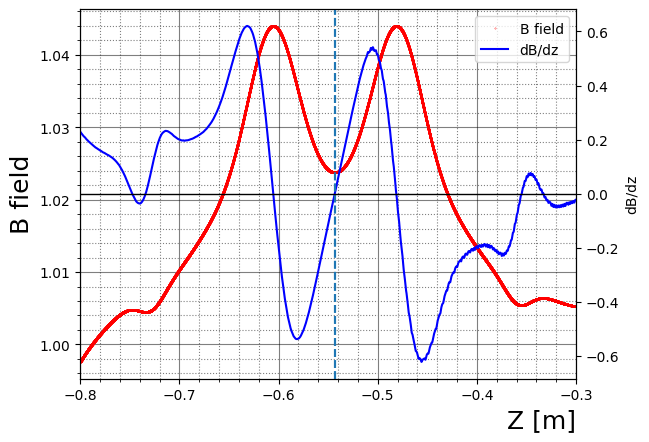

In [104]:
fig, ax1 = plt.subplots()

plotter_nicer("Z [m]", "Total Potential")
ax1.set_xlim(-0.800, -0.300)

# Primo asse y (ad esempio per il potenziale)
ax1.plot(zgrid, Bfield_20mT_pregravity_grid, linestyle="", marker = ".", markersize = 0.5, color="red", label="B field")

# Secondo asse y per la derivata
ax2 = ax1.twinx()
ax2.plot(zgrid, dBfield_20mT_pregravity_dz, color="blue", label="dB/dz")
#ax2.axvline(CONSTANTS.Zmid)

ax2.axvline(CONSTANTS.Zmid, linestyle = "--")
ax2.axvline(CONSTANTS.Zmid + 0.0005, linestyle = "--")
ax2.axhline(0., linestyle = "-", color = "black", linewidth = 1)

# Etichette
ax1.set_ylabel("B field")
ax2.set_ylabel("dB/dz")

# Se vuoi una legenda combinata:
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.show()

In [105]:
# test gradient computation
a = dB_seg(CONSTANTS.Zmid,0,0,
       0,10,
       z0, dz,
       dBfield_20mT_pregravity_dz,
       Bfield_20mT_pregravity_grid,
       dBfield_17mT_dz,
       Bfield_17mT_grid)
print(f"[{a[0]},{a[1]},{a[2]}]")

a = dB_seg(-0.51,0,0,
       0,10,
       z0, dz,
       dBfield_20mT_pregravity_dz,
       Bfield_20mT_pregravity_grid,
       dBfield_17mT_dz,
       Bfield_17mT_grid)
print(f"[{a[0]},{a[1]},{a[2]}]")

[0.0,0.0,0.00104127983235891]
[0.0,0.0,0.5228327002899658]


## Test 3d Initial Conditions

In [111]:
mask = (zgrid > CONSTANTS.Zmin) & (zgrid < CONSTANTS.Zmax)
idx = np.argmin(Bfield_20mT_pregravity(zgrid[mask]))

print(zgrid[mask][idx])

-0.5433774337743378


In [113]:
# Reset All
V_array, R_array, Time_Annihilation, Annihilation = cleaner(V_array, R_array, Time_Annihilation, Annihilation)

for _ in range(nAtoms):
    #print("Extracting values:")
    Vinit, Rinit = InitialCondition_3d(Bfield_20mT_pregravity, CONSTANTS) # initial conditions
    R_array.append(Rinit)
    #V_array.append([Vinit[0],Vinit[1],Vinit[2]])      # Initial speed
    V_array.append([0,0,Vinit[2]])
    Time_Annihilation.append(np.nan)  # Time annihilation
    Annihilation.append(False)        # Annihilation bool array

# convert to np array
V_array, R_array, Time_Annihilation, Annihilation = convert_np(V_array, R_array, Time_Annihilation, Annihilation)

total energy  1.1364526615214647e-26 Max Energy  1.8750733888240268e-25
total energy  4.1490956460128175e-26 Max Energy  1.8750733888240268e-25
total energy  1.3440627179516444e-26 Max Energy  1.8750733888240268e-25
total energy  6.693390756377584e-27 Max Energy  1.8750733888240268e-25
total energy  1.9053309020618044e-29 Max Energy  1.8750733888240268e-25
total energy  2.1457852523007233e-27 Max Energy  1.8750733888240268e-25
total energy  4.221511013148975e-28 Max Energy  1.8750733888240268e-25
total energy  1.517546265467289e-28 Max Energy  1.8750733888240268e-25
total energy  4.692675752594055e-30 Max Energy  1.8750733888240268e-25
total energy  5.523322674467485e-27 Max Energy  1.8750733888240268e-25
total energy  1.2999542409911524e-29 Max Energy  1.8750733888240268e-25
total energy  3.1099865720222756e-26 Max Energy  1.8750733888240268e-25
total energy  1.3940907531119704e-26 Max Energy  1.8750733888240268e-25
total energy  3.058827833094063e-28 Max Energy  1.8750733888240268e-2

### Plot the Energy Distribution at $t = 0$

[0. 0. 0. ... 0. 0. 0.]
<class 'numpy.float64'>
Tx after 0s: 0.0 mK
Ty after 0s: 0.0 mK
Tz after 0s: 2.0134908728693848 mK
Tglobal  0s: 0.6711636242897948 mK


Text(0, 0.5, 'counts')

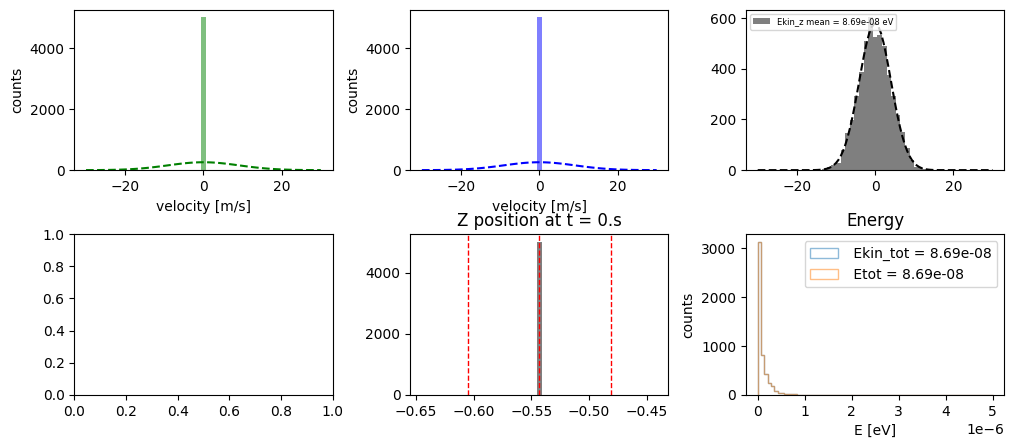

In [114]:
radius   = np.sqrt(R_array[:,0]**2 + R_array[:,1]**2)
U0       = Bfield_20mT_pregravity(CONSTANTS.Zmid)
Uxyz     = BfieldExtended(Bfield_20mT_pregravity, R_array[:,2], radius, CONSTANTS)
Up       =  (Uxyz - U0) * CONSTANTS.bohr_magneton   / 1.6e-19
Ekin_z   =  (.5 * CONSTANTS.mass * V_array[:,2]**2) / 1.6e-19
Ekin_x   =  (.5 * CONSTANTS.mass * V_array[:,0]**2) / 1.6e-19
Ekin_y   =  (.5 * CONSTANTS.mass * V_array[:,1]**2) / 1.6e-19
Ekin_tot =  Ekin_z + Ekin_x + Ekin_y
Etot     =  Up + Ekin_z + Ekin_x + Ekin_y
print(Up)

sigmax = np.std(V_array[:,0])
sigmay = np.std(V_array[:,1])
sigmaz = np.std(V_array[:,2])

#print(V_array[:,0])

Tx = sigmaToTemperature_n(sigmax, CONSTANTS.kB, CONSTANTS.mass)
Ty = sigmaToTemperature_n(sigmay, CONSTANTS.kB, CONSTANTS.mass)
Tz = sigmaToTemperature_n(sigmaz, CONSTANTS.kB, CONSTANTS.mass)

print(type(Tx))
print(f"Tx after 0s: {Tx * 1e3} mK")
print(f"Ty after 0s: {Ty * 1e3} mK")
print(f"Tz after 0s: {Tz * 1e3} mK")
print(f"Tglobal  0s: {sigmaToTemperature_3(sigmax,sigmay, sigmaz, CONSTANTS.kB, CONSTANTS.mass)*1e3} mK")

xgrid = np.linspace(-30,30, 100)
delta = 60/51

plt.figure(56, figsize = (12,5))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.subplot(2,3,1)
plt.hist(V_array[:,0], range = (-30, 30), bins = 51, color = "green", alpha = .5)
sigmax = TemperatureTosigma(CONSTANTS.Temperature_transv,CONSTANTS.kB, CONSTANTS.mass)
plt.plot(xgrid, delta*function(xgrid, nAtoms, sigmax), linestyle = "--", color = "green")
plt.xlabel("velocity [m/s]")
plt.ylabel("counts")

plt.subplot(2,3,2)
plt.hist(V_array[:,1], range = (-30, 30), bins = 51, alpha = .5, color = "blue")
sigmay = TemperatureTosigma(CONSTANTS.Temperature_transv,CONSTANTS.kB, CONSTANTS.mass)
plt.plot(xgrid, delta*function(xgrid, nAtoms, sigmax), linestyle = "--", color = "blue")
plt.xlabel("velocity [m/s]")
plt.ylabel("counts")

plt.subplot(2,3,3)
plt.hist(V_array[:,2], range = (-30, 30), bins = 51, alpha = .5, color = "black", label = f"Ekin_z mean = {np.mean(Ekin_z):.3} eV")
sigmaz = TemperatureTosigma(CONSTANTS.Temperature,CONSTANTS.kB, CONSTANTS.mass)
plt.plot(xgrid, delta*function(xgrid, nAtoms, sigmaz), linestyle = "--", color = "black")
plt.legend(fontsize = 6, loc = "upper left")

ax = plt.subplot(2,3,4)

ax = plt.subplot(2,3,5)
ax.set_title("Z position at t = 0.s")
plt.hist(R_array[:,2], range = (CONSTANTS.Zmin - 0.05, CONSTANTS.Zmax + 0.05), bins = 51, alpha = .5, color = "black")
plt.axvline(CONSTANTS.Zmax, linestyle = "--", color = "red", linewidth = 1)
plt.axvline(CONSTANTS.Zmin, linestyle = "--", color = "red", linewidth = 1)
plt.axvline(CONSTANTS.Zmid, linestyle = "--", color = "red", linewidth = 1)
plt.xlim(CONSTANTS.Zmin - 0.05, CONSTANTS.Zmax + 0.05)

ax = plt.subplot(2,3,6)
ax.set_title("Energy")
#plt.hist(Up, bins = 51, alpha = .5, histtype = 'step', label =f" Umean = {np.mean(Up):.3}" )
plt.hist(Ekin_tot, bins = 71,range = (0, 5e-6), alpha = .5, histtype = 'step', label =f" Ekin_tot = {np.mean(Ekin_tot):.3}")
plt.hist(Etot,     bins = 71,range = (0, 5e-6), alpha = .5, histtype = 'step', label =f" Etot = {np.mean(Etot):.3}")
plt.legend()
plt.xlabel("E [eV]")
plt.ylabel("counts")

### $\delta t = 2.5$s evolution

In [82]:
Total_Time_Simulation = 10
Time = 0

Ekin_evo_z = []
Ekin_evo_y = []
Ekin_evo_x = []
Etot_evo   = []
Up_evo     = []
Time_array = []

for frame in range(0,int(Total_Time_Simulation/dt)):
    seg_id   = 1   # plateau
    Tloc     = 0.0
    ramp_len = 0.0
    dBinit   = dBfield_20mT_pregravity_dz  # non usato
    Binit    = Bfield_20mT_pregravity_grid 
    dBfinal  = dBfield_20mT_pregravity_dz  # usi questo
    Bfinal   = Bfield_20mT_pregravity_grid

    # step di tutte le particelle (in-place)
    step_all_particles(
        R_array, V_array, Time,
        seg_id, Tloc, ramp_len,
        z0, dz,
        dBinit, Binit, dBfinal, Bfinal,
        Annihilation, Time_Annihilation,
        dB_buffer,
        theta, tau_mixing)

    if(frame % 100 == 0):
        #print(f"frame {frame}, time {Time:.5f}s, ({R_array[0,0]*1e3:.2f},{R_array[0,1]*1e3:.2f},{ (R_array[0,2] - CONSTANTS.Zmid)*1e3:.2f}) mm, V ({V_array[0,0]:.2f},{V_array[0,1]:.2f},{V_array[0,2]:.2f})")
        # debug quantities
        Time_array.append(Time)
        
        radius = np.sqrt(R_array[:,0]**2 + R_array[:,1]**2)
        U0   = Bfield_20mT_pregravity(CONSTANTS.Zmid)
        Uxyz = BfieldExtended(Bfield_20mT_pregravity, R_array[:,2] , radius, CONSTANTS)
        Up     =  (Uxyz - U0) * CONSTANTS.bohr_magneton   / 1.6e-19
        Ekin_z =  (.5 * CONSTANTS.mass * V_array[:,2]**2) / 1.6e-19
        Ekin_x =  (.5 * CONSTANTS.mass * V_array[:,0]**2) / 1.6e-19
        Ekin_y =  (.5 * CONSTANTS.mass * V_array[:,1]**2) / 1.6e-19
        
        Ekin_evo_z.append(np.mean(Ekin_z))
        Ekin_evo_x.append(np.mean(Ekin_x))
        Ekin_evo_y.append(np.mean(Ekin_y))
        Up_evo.append(np.mean(Up))
        Etot_evo.append(np.mean(Up) + np.mean(Ekin_z) + np.mean(Ekin_x) + np.mean(Ekin_y))
    # Avanza il tempo UNA volta per frame
    Time += dt 

<class 'numpy.float64'>
Tx after 0s: 7.57569262272214 mK
Ty after 0s: 7.630392381503409 mK
Tz after 0s: 3.0628253103492846 mK
Tglobal  0s: 6.089636771524945 mK


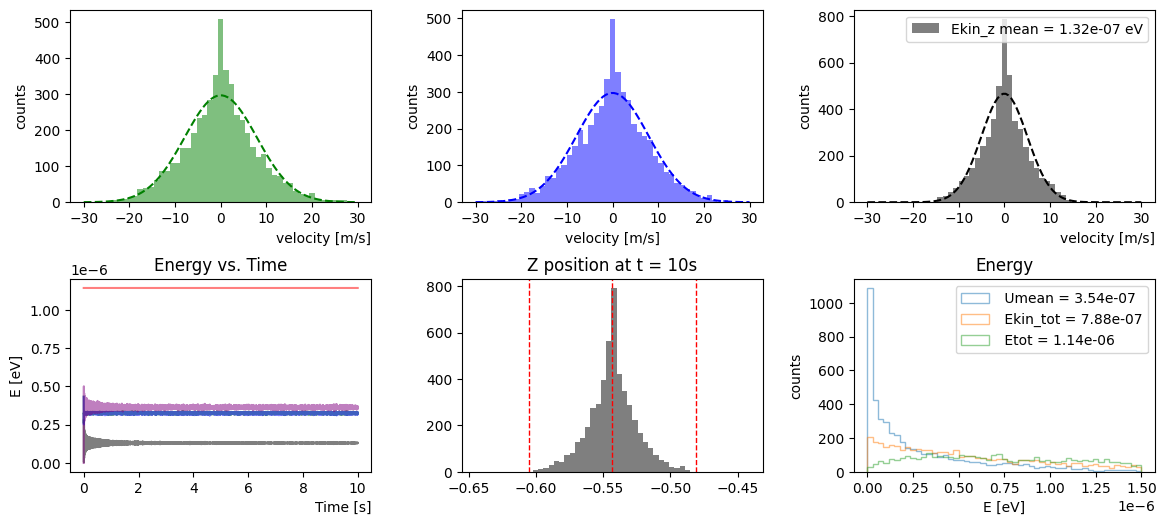

In [83]:
radius = np.sqrt(R_array[:,0]**2 + R_array[:,1]**2)
U0   = Bfield_20mT_pregravity(CONSTANTS.Zmid)
Uxyz = BfieldExtended(Bfield_20mT_pregravity, R_array[:,2] , radius, CONSTANTS)
Up     =  (Uxyz - U0) * CONSTANTS.bohr_magneton   / 1.6e-19
Ekin_z =  (.5 * CONSTANTS.mass * V_array[:,2]**2) / 1.6e-19
Ekin_x =  (.5 * CONSTANTS.mass * V_array[:,0]**2) / 1.6e-19
Ekin_y =  (.5 * CONSTANTS.mass * V_array[:,1]**2) / 1.6e-19
Ekin_tot = Ekin_z + Ekin_x + Ekin_y
Etot = Up + Ekin_z + Ekin_x + Ekin_y

sigmax = np.std(V_array[:,0])
sigmay = np.std(V_array[:,1])
sigmaz = np.std(V_array[:,2])

#print(V_array[:,0])

Tx = sigmaToTemperature_n(sigmax, CONSTANTS.kB, CONSTANTS.mass)
Ty = sigmaToTemperature_n(sigmay, CONSTANTS.kB, CONSTANTS.mass)
Tz = sigmaToTemperature_n(sigmaz, CONSTANTS.kB, CONSTANTS.mass)

print(type(Tx))
print(f"Tx after 0s: {Tx * 1e3} mK")
print(f"Ty after 0s: {Ty * 1e3} mK")
print(f"Tz after 0s: {Tz * 1e3} mK")
print(f"Tglobal  0s: {sigmaToTemperature_3(sigmax,sigmay, sigmaz, CONSTANTS.kB, CONSTANTS.mass)*1e3} mK")

xgrid = np.linspace(-30,30, 100)
delta = 60/51

plt.figure(3, figsize = (14,6))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.subplot(2,3,1)
plt.hist(V_array[:,0], range = (-30, 30), bins = 51, color = "green", alpha = .5)
sigmax = TemperatureTosigma(Tx,CONSTANTS.kB, CONSTANTS.mass)
plt.plot(xgrid, delta*function(xgrid, nAtoms, sigmax), linestyle = "--", color = "green")
plt.xlabel("velocity [m/s]", loc = "right")
plt.ylabel("counts")

plt.subplot(2,3,2)
plt.hist(V_array[:,1], range = (-30, 30), bins = 51, alpha = .5, color = "blue")
sigmay = TemperatureTosigma(Ty,CONSTANTS.kB, CONSTANTS.mass)
plt.plot(xgrid, delta*function(xgrid, nAtoms, sigmax), linestyle = "--", color = "blue")
plt.xlabel("velocity [m/s]")
plt.ylabel("counts")

plt.subplot(2,3,3)
plt.hist(V_array[:,2], range = (-30, 30), bins = 51, alpha = .5, color = "black", label = f"Ekin_z mean = {np.mean(Ekin_z):.3} eV")
sigmaz = TemperatureTosigma(Tz,CONSTANTS.kB, CONSTANTS.mass)
plt.plot(xgrid, delta*function(xgrid, nAtoms, sigmaz), linestyle = "--", color = "black")
plt.xlabel("velocity [m/s]", loc = "right")
plt.ylabel("counts")
plt.legend()

ax = plt.subplot(2,3,4)
ax.set_title("Energy vs. Time")
plt.plot(Time_array, Ekin_evo_z, color = "black", alpha = .5)
plt.plot(Time_array, Ekin_evo_x, color = "green", alpha = .5)
plt.plot(Time_array, Ekin_evo_y, color = "blue", alpha = .5)
plt.plot(Time_array, Up_evo, color   = "purple", alpha = .5)
plt.plot(Time_array, Etot_evo, color = "red", alpha = .5)
#plt.xlim(0,0.1)
plt.xlabel("Time [s]", loc = "right")
plt.ylabel("E [eV]")
#plt.ylim(0, 8e-7)

ax = plt.subplot(2,3,5)
ax.set_title(f"Z position at t = {Total_Time_Simulation}s")
plt.hist(R_array[:,2], bins = 30, alpha = .5, color = "black")
plt.axvline(CONSTANTS.Zmax, linestyle = "--", color = "red", linewidth = 1)
plt.axvline(CONSTANTS.Zmin, linestyle = "--", color = "red", linewidth = 1)
plt.axvline(CONSTANTS.Zmid, linestyle = "--", color = "red", linewidth = 1)
plt.xlim(CONSTANTS.Zmin - 0.05, CONSTANTS.Zmax + 0.05)

ax = plt.subplot(2,3,6)
ax.set_title("Energy")

plt.hist(Up,       bins = 51,range = (0,1.5e-6), alpha = .5, histtype = 'step', label =f" Umean = {np.mean(Up):.3}" )
plt.hist(Ekin_tot, bins = 51,range = (0,1.5e-6), alpha = .5, histtype = 'step', label =f" Ekin_tot = {np.mean(Ekin_tot):.3}")
plt.hist(Etot,     bins = 51,range = (0,1.5e-6), alpha = .5, histtype = 'step', label =f" Etot = {np.mean(Etot):.3}")
plt.legend()
plt.xlabel("E [eV]")
plt.ylabel("counts")
plt.savefig("Energytest_after.png", bbox_inches = "tight")

# Test Mixing, Rotation Matrix

In [ ]:
from UTILS import rotation_matrix_axis_angle, sample_random_axis

vec    = [1,0,0]
axis   = [0,0,1]

R = rotation_matrix_axis_angle(axis, np.pi/4)
vec2 = R @ vec

print(f"starting vec: {vec}; rotated Vector {vec2}")

vec  = [1,0,0]
axis = [0,1,1]

R = rotation_matrix_axis_angle(axis, np.pi/2)
vec2 = R @ vec

print(f"starting vec: {vec}; rotated Vector {vec2}")

# Test Simulation: 1 particle evolution

## Measuring Bouncing frequency, 5mK in 17mT well

In [ ]:
# Reset All
Time = 0
V_array, R_array, Time_Annihilation, Annihilation = cleaner(V_array, R_array, Time_Annihilation, Annihilation)

Vinit, Rinit = InitialCondition_3d(Bfield_20mT_pregravity, CONSTANTS) # Define initial conditions of the simulation

T_axial  = 5e-3
T_transv = 0

v_axial  = np.sqrt(CONSTANTS.kB * T_axial / CONSTANTS.mass)
v_transv = np.sqrt(CONSTANTS.kB * T_transv / CONSTANTS.mass)

Vinit[0] = 0
Vinit[1] = 0
Vinit[2] = v_axial

# Initialize with initial conditions
R_array.append(Rinit)
V_array.append(Vinit)             # Initial speed
Time_Annihilation.append(np.nan)  # Time annihilation
Annihilation.append(False)

# convert to np array
V_array, R_array, Time_Annihilation, Annihilation = convert_np(V_array, R_array, Time_Annihilation, Annihilation)

In [ ]:
start_time = time.time()

Xv = []
Yv = []
Zv = []

Vxv = []
Vyv = []
Vzv = []

rev_counter = 0

Total_Time_Simulation = 10

for frame in range(0,int(Total_Time_Simulation/dt)):
    seg_id   = 1   # plateau
    Tloc     = 0.0
    ramp_len = 0.0
    dBinit   = dBfield_20mT_pregravity_dz  # non usato
    Binit    = Bfield_20mT_pregravity_grid 
    dBfinal  = dBfield_17mT_dz             # usi questo
    Bfinal   = Bfield_17mT_grid

    # step di tutte le particelle (in-place)
    step_all_particles(
        R_array, V_array, Time,
        seg_id, Tloc, ramp_len,
        z0, dz,
        dBinit, Binit, dBfinal, Bfinal,
        Annihilation, Time_Annihilation,
        dB_buffer,
        theta, tau_mixing)

    if(frame % 1 == 0):
        print(f"frame {frame}, time {Time:.5f}s, ({R_array[0,0]*1e3:.2f},{R_array[0,1]*1e3:.2f},{ (R_array[0,2] - CONSTANTS.Zmid)*1e3:.2f}) mm, V ({V_array[0,0]:.2f},{V_array[0,1]:.2f},{V_array[0,2]:.2f})")
    
    # Get trajectory
    Xv.append(R_array[0,0])
    Yv.append(R_array[0,1])
    Zv.append(R_array[0,2])

    Vxv.append(V_array[0,0])
    Vyv.append(V_array[0,1])
    Vzv.append(V_array[0,2])
    # Avanza il tempo UNA volta per frame
    Time += dt

In [ ]:
time_grid = np.linspace(0, Total_Time_Simulation ,int(Total_Time_Simulation/dt)); print(time_grid)

def lawofmotion(t, omega, offset, scale):
    return scale*np.sin(omega*t) + offset

omega = 2*np.pi* (1 / 0.0224)
print(f"frequency is {omega / 2*np.pi} Hz")

# Plot layout
plt.figure(1, figsize = (20,10))
plt.title(f"Z position as function of time, Ekin_z = {CONSTANTS.Temperature*1e3} mK")
plt.xlabel("Time")
plt.xlim(0,0.5)

a = plt.plot(time_grid[::10], Zv[::10])
a = plt.plot(time_grid[::10], lawofmotion(time_grid[::10], omega , +CONSTANTS.Zmid, 0.023) ,linestyle = "--", color = "black")
a = plt.xticks(np.linspace(0,0.5,20))

## Measuring Bouncing Frequency 1mK in 17mT well

In [ ]:
# Reset All
Time = 0
V_array, R_array, Time_Annihilation, Annihilation = cleaner(V_array, R_array, Time_Annihilation, Annihilation)

Vinit, Rinit = InitialCondition_3d(Bfield_20mT_pregravity, CONSTANTS) # Define initial conditions of the simulation

T_axial = 1.125e-3
v_axial  = np.sqrt(CONSTANTS.kB * T_axial / CONSTANTS.mass)
v_transv = np.sqrt(CONSTANTS.kB * T_axial / CONSTANTS.mass)

Vinit[0] = 0
Vinit[1] = 0
Vinit[2] = v_axial

# Initial position
R_array.append(Rinit)
V_array.append(Vinit)             # Initial speed
Time_Annihilation.append(np.nan)  # Time annihilation
Annihilation.append(False)

# convert to np array
V_array, R_array, Time_Annihilation, Annihilation = convert_np(V_array, R_array, Time_Annihilation, Annihilation)

In [ ]:
start_time = time.time()

Xv = []
Yv = []
Zv = []

Vxv = []
Vyv = []
Vzv = []

rev_counter = 0

Total_Time_Simulation = 10

for frame in range(0,int(Total_Time_Simulation/dt)):
    seg_id   = 1   # plateau
    Tloc     = 0.0
    ramp_len = 0.0
    dBinit   = dBfield_20mT_pregravity_dz  # non usato
    Binit    = Bfield_20mT_pregravity_grid 
    dBfinal  = dBfield_17mT_dz             # usi questo
    Bfinal   = Bfield_17mT_grid

    # step di tutte le particelle (in-place)
    step_all_particles(
        R_array, V_array, Time,
        seg_id, Tloc, ramp_len,
        z0, dz,
        dBinit, Binit, dBfinal, Bfinal,
        Annihilation, Time_Annihilation,
        dB_buffer,
        theta, tau_mixing)

    if(frame % 1 == 0):
        print(f"frame {frame}, time {Time:.5f}s, ({R_array[0,0]*1e3:.2f},{R_array[0,1]*1e3:.2f},{ (R_array[0,2] - CONSTANTS.Zmid)*1e3:.2f}) mm, V ({V_array[0,0]:.2f},{V_array[0,1]:.2f},{V_array[0,2]:.2f})")
    
    # Get trajectory
    Xv.append(R_array[0,0])
    Yv.append(R_array[0,1])
    Zv.append(R_array[0,2])

    Vxv.append(V_array[0,0])
    Vyv.append(V_array[0,1])
    Vzv.append(V_array[0,2])

    
    
    # Avanza il tempo UNA volta per frame
    Time += dt

In [ ]:
time_grid = np.linspace(0, Total_Time_Simulation ,int(Total_Time_Simulation/dt)); print(time_grid)

def lawofmotion(t, omega, offset, scale):

    return scale*np.sin(omega*t) + offset

omega = 2*np.pi* (1 / 0.0225)
print(f"frequency is {omega / 2*np.pi} Hz")


# Plot layout
plt.figure(1, figsize = (20,10))
plt.title(f"Z position as function of time, Ekin_z = {T_axial*1e3} mK")
plt.xlabel("Z", fontsize = 20)
plt.xlim(0,0.5)

a = plt.plot(time_grid[::10], Zv[::10])
a = plt.plot(time_grid[::10], lawofmotion(time_grid[::10], omega , +CONSTANTS.Zmid, 0.012) ,linestyle = "--", color = "black")
a = plt.xticks(np.linspace(0,0.5,20))

## Mesuring Bouncing Frequency, 1mK in 5mT well

In [ ]:
# Reset All
Time = 0
V_array, R_array, Time_Annihilation, Annihilation = cleaner(V_array, R_array, Time_Annihilation, Annihilation)

Vinit, Rinit = InitialCondition_3d(Bfield_20mT_pregravity, CONSTANTS) # Define initial conditions of the simulation

T_axial  = 5.6e-3
v_axial  = np.sqrt(CONSTANTS.kB * T_axial / CONSTANTS.mass)
v_transv = np.sqrt(CONSTANTS.kB * 1.125e-3 / CONSTANTS.mass)

Vinit[0] = 0
Vinit[1] = 0
Vinit[2] = v_axial

# Initial position
R_array.append(Rinit)
V_array.append(Vinit)             # Initial speed
Time_Annihilation.append(np.nan)  # Time annihilation
Annihilation.append(False)

# convert to np array
V_array, R_array, Time_Annihilation, Annihilation = convert_np(V_array, R_array, Time_Annihilation, Annihilation)

In [ ]:
start_time = time.time()

Xv = []
Yv = []
Zv = []

Vxv = []
Vyv = []
Vzv = []

rev_counter = 0

Total_Time_Simulation = 10

for frame in range(0,int(Total_Time_Simulation/dt)):
    seg_id   = 1   # plateau
    Tloc     = 0.0
    ramp_len = 0.0
    dBinit   = dBfield_5mT_dz  # non usato
    Binit    = Bfield_5mT_grid 
    dBfinal  = dBfield_5mT_dz             # usi questo
    Bfinal   = Bfield_5mT_grid

    # step di tutte le particelle (in-place)
    step_all_particles(
        R_array, V_array, Time,
        seg_id, Tloc, ramp_len,
        z0, dz,
        dBinit, Binit, dBfinal, Bfinal,
        Annihilation, Time_Annihilation,
        dB_buffer,
        theta, tau_mixing)

    if(frame % 1 == 0):
        print(f"frame {frame}, time {Time:.5f}s, ({R_array[0,0]*1e3:.2f},{R_array[0,1]*1e3:.2f},{ (R_array[0,2] - CONSTANTS.Zmid)*1e3:.2f}) mm, V ({V_array[0,0]:.2f},{V_array[0,1]:.2f},{V_array[0,2]:.2f})")
    
    # Get trajectory
    Xv.append(R_array[0,0])
    Yv.append(R_array[0,1])
    Zv.append(R_array[0,2])

    Vxv.append(V_array[0,0])
    Vyv.append(V_array[0,1])
    Vzv.append(V_array[0,2])

    
    
    # Avanza il tempo UNA volta per frame
    Time += dt

In [ ]:
time_grid = np.linspace(0, Total_Time_Simulation ,int(Total_Time_Simulation/dt)); print(time_grid)

def lawofmotion(t, omega, offset, scale):

    return scale*np.sin(omega*t) + offset

omega = 2*np.pi* (1 / 0.044)
print(f"frequency is {omega / 2*np.pi} Hz")


# Plot layout
plt.figure(1, figsize = (20,10))
plt.title(f"Z position as function of time, Ekin_z = {T_axial*1e3} mK")
plt.xlabel("Z")
plt.xlim(0,0.5)

a = plt.plot(time_grid[::10], Zv[::10])
a = plt.plot(time_grid[::10], lawofmotion(time_grid[::10], omega , +CONSTANTS.Zmid, 0.022) ,linestyle = "--", color = "black")
a = plt.xticks(np.linspace(0,0.5,20))

In [ ]:
def grid_plotter(zc, height):
    xx = np.ones(100)*zc
    zz = np.ones(100)*(height)
    yy = np.linspace(-0.0250, 0.0250, 100)
    ax.plot(xx, yy, zz, linestyle = "--", color = "black", alpha = 0.75)
    ax.plot(xx, zz, yy, linestyle = "--", color = "black", alpha = .75)

In [ ]:
#%matplotlib widget

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

start = 0
end = 2000

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# plot starting point
ax.scatter(Zv[start], Xv[start], Yv[start], color = "blue", marker = "x")
# plot ending point
ax.scatter(Zv[end], Xv[end], Yv[end], color = "red", marker = "x")
# plot the trajectory
ax.plot(Zv[:end], Xv[:end], Yv[:end])

height = np.linspace(-0.02/2, 0.02/2, 3)

for h in height:
    grid_plotter(CONSTANTS.Zmin, h)
    grid_plotter(CONSTANTS.Zmax, h)


ax.set_xlim(-0.800, -0.300) # X axis -> Z variable
ax.set_ylim(-0.0250/1, +0.0250/1) # Y axis -> X variable
ax.set_zlim(-0.0250/1, +0.0250/1) # Z axis -> Y variable

ax.set_xlabel("Z")
ax.set_ylabel("X")
ax.set_zlabel("Y")

plt.show()

# Visualization of the motion inside the Potential Well

In [ ]:
def BfieldExtended(function, X, Y, Z, k, p):
    "3d extent of the magnetic field model, assuming harmonic potential"
    r = np.sqrt(X*X + Y*Y)
    return function(Z) * (1 + k*r**p)

def slice_plotter(f, Bfield, zc, height, alpha, ax):
    zcomp = np.linspace(-0.7, -0.4, 100)
    ycomp = np.ones(100)*(0)
    xcomp = np.ones(100)*(height)
    
    Potential = f(Bfield, 
               xcomp, 
               ycomp, # y component
               zcomp, # z component
               harmonic_coefficient, harmonic_degree)*1e4
    Potential -= f(Bfield, 
               0, 
               0, # y component
               CONSTANTS.Zmid, # z component
               harmonic_coefficient, harmonic_degree)*1e4
    ax.plot(zcomp, xcomp , Potential, linestyle = "--", color = "black", alpha = alpha)

# Visualization of the Motion in the Z-X plane, with slice of the magnetic field potential

In [ ]:
# fig = plt.figure(2)
# ax = fig.add_subplot(111, projection='3d')

start = 0
end = 5000

fig = plt.figure()
ax1 = fig.add_subplot(111, projection='3d')

# Trajectoy in Potential
Potential = BfieldExtended(Bfield_5mT, np.array(Xv), np.array(Yv),np.array(Zv),
                           harmonic_coefficient, harmonic_degree)*1e4 

Potential -= BfieldExtended(Bfield_5mT, 0,0, CONSTANTS.Zmid,
                           harmonic_coefficient, harmonic_degree)*1e4

# Plot trajectory in the potential well
ax1.plot(Zv[:end], 
         np.sqrt(np.array(Xv[:end])**2 + np.array(Yv[:end])**2),
         Potential[:end], 
         linestyle = "dotted")

#slice


height = np.linspace(0, 0.02, 10)

for h in height:
    alpha = 0.5
    slice_plotter(BfieldExtended, Bfield_5mT, 0, h, alpha, ax1)
    slice_plotter(BfieldExtended, Bfield_5mT, 0, h, alpha, ax1)

# ax.set_xlim(-0.800, -0.300)
# ax.set_ylim(-0.250, +0.250)
# ax.set_zlim(-0.250, +0.250)

ax1.set_xlabel("Z [m]")
ax1.set_ylabel("R [m]")
ax1.set_zlabel("Potential")

#plt.show()

## Visualize potential

In [ ]:

plt.figure(4)

x = np.linspace(0, 0.020, 100)

degree = 2.2
k      = 50
Potential = BfieldExtended(Bfield_17mT, 
                           x, 
                           np.ones(100)*0,
                           np.ones(100)*CONSTANTS.Zmid,
                           k, 
                           degree) * 10000
Potential -= min(Potential)
plt.plot(x*1000, Potential, label = f"p = {degree}, k = {k}")

degree = 2.
k      = 50
Potential = BfieldExtended(Bfield_17mT, 
                           x, 
                           np.ones(100)*0,
                           np.ones(100)*CONSTANTS.Zmid,
                           k, 
                           degree) * 10000
Potential -= min(Potential)
plt.plot(x*1000, Potential, label = f"p = {degree}, k = {k}")

degree = 1.9
k      = 50
Potential = BfieldExtended(Bfield_17mT, 
                           x, 
                           np.ones(100)*0,
                           np.ones(100)*CONSTANTS.Zmid,
                           k, 
                           degree) * 10000
Potential -= min(Potential)
plt.plot(x*1000, Potential, label = f"p = {degree}, k = {k}")

degree = 6
k      = 2.37200451e8
Potential = BfieldExtended(Bfield_17mT, 
                           x, 
                           np.ones(100)*0,
                           np.ones(100)*CONSTANTS.Zmid,
                           k, 
                           degree) * 10000
Potential -= min(Potential)
plt.plot(x*1000, Potential, color = "black", linestyle = "--" ,label = f"p = {degree}, k = {k}")

plt.axhline(200, linestyle = "--", color = "black")
plt.axhline(300, linestyle = "--", color = "black")
plt.axhline(100, linestyle = "--", color = "black")
plt.xlabel("mm")

plt.legend()
plt.show()

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from UTILS import harmonic_degree, harmonic_coefficient

In [ ]:
R, Bfield = np.loadtxt("Radius.txt", unpack = True, delimiter = ",")

print(R, Bfield)

R = R # mm -> m
Bfield = Bfield

In [ ]:
from scipy.optimize import curve_fit

def model(R, k):
    return (k*1e4) * R**(6)

p0 = [harmonic_coefficient, harmonic_degree]
popt, pcovm =  curve_fit(model, R*1e-3, Bfield, p0 = [harmonic_coefficient])

print(popt)

plt.figure(23)
plt.grid()
zgrid = np.linspace(0, 21, 100)
#plt.plot(zgrid, model(zgrid, 5e-11), linestyle = "dotted", color = "blue")
plt.plot(zgrid, model(zgrid*1e-3, *popt), linestyle = "dotted", color = "black", label = f"{popt}")
plt.errorbar(R, Bfield, color = "green")
plt.xlabel("mm")

plt.legend()
plt.show()